In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import torchvision
from torch.utils.tensorboard import SummaryWriter

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
import os

data_dir = r"C:\Users\J Birbou\ML_Class\HW2"
spectra = np.load(os.path.join(data_dir, "spectra.npy"))
spectra_length = spectra.shape[1]
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(os.path.join(data_dir, "labels.npy"))
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]
spectra = np.log(np.maximum(spectra, 0.2))

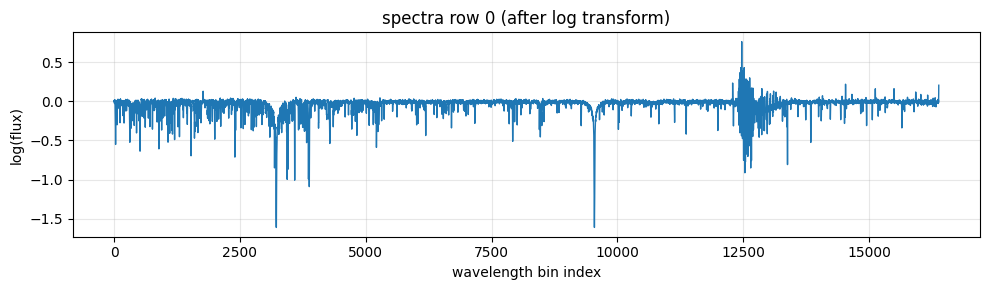

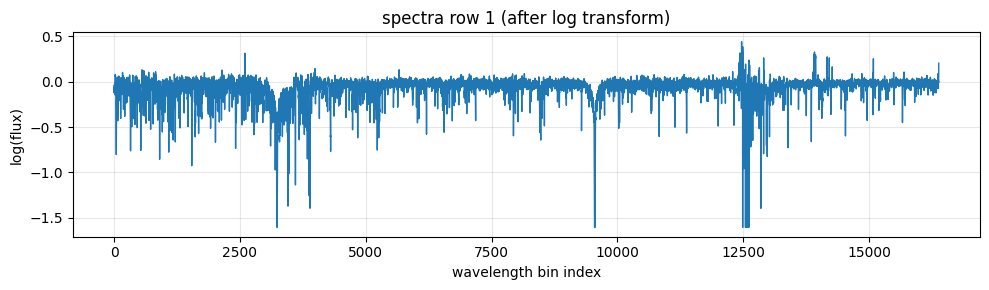

In [ ]:
import matplotlib.pyplot as plt

for i in range(2):  
    plt.figure(figsize=(10, 3))
    plt.plot(spectra[i], lw=1)
    plt.title(f"spectra row {i} (after log transform)")
    plt.xlabel("wavelength bin index")
    plt.ylabel("log(flux)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
#normalize labels
labels_mean = labels.mean(axis=0)
labels_std = labels.std(axis=0)
labels = (labels - labels_mean) / labels_std

#normalize spectra
spectra_mean = spectra.mean(axis=0)
spectra_std = spectra.std(axis=0)
spectra = (spectra - spectra_mean) / spectra_std

# Convert to tensors
spectra_tensor = torch.from_numpy(spectra).float()
labels_tensor = torch.from_numpy(labels).float()

print(f"spectra_tensor dtype: {spectra_tensor.dtype}, shape: {spectra_tensor.shape}")
print(f"labels_tensor dtype: {labels_tensor.dtype}, shape: {labels_tensor.shape}")

# Move to device
spectra_tensor = spectra_tensor.to(device)
labels_tensor = labels_tensor.to(device)

print(f"spectra_tensor device: {spectra_tensor.device}")
print(f"labels_tensor device: {labels_tensor.device}")





spectra_tensor dtype: torch.float32, shape: torch.Size([8914, 16384])
labels_tensor dtype: torch.float32, shape: torch.Size([8914, 3])
spectra_tensor device: cuda:0
labels_tensor device: cuda:0


In [6]:
# Split data
num_samples = spectra_tensor.shape[0]
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

# Use TensorDataset to create a dataset
train_dataset, val_dataset, test_dataset \
= random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 64  # increased from 10 for better GPU utilization
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 6239, Val: 1337, Test: 1338


In [ ]:
# --- Model and Loss Definition ---
def nll_loss(predictions, batch_labels, epoch, warmup_epochs=0):
    mean = predictions[:, :3]  
    raw_log_std = predictions[:, 3:]
    
    #log_std = torch.clamp(raw_log_std, min=-2.0, max=0.5)
    log_std = raw_log_std
    if epoch < warmup_epochs:
        return torch.mean((batch_labels - mean) ** 2)
    else:
        std = torch.exp(log_std)  
        eps = 1e-6 
        return torch.mean((0.5 * ((batch_labels - mean) / (std + eps)) ** 2) + log_std)


In [ ]:
EPOCHS = 100
LEARNING_RATE = 0.0003
INPUT_SIZE = 16384
import torch
import torch.nn as nn
nLabels = 6
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.model = nn.Sequential(
            
            nn.Conv1d(1, 10, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),
            
            nn.Conv1d(10, 20, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(20),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),
            
            nn.Conv1d(20, 40, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(40),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),
           
            nn.Conv1d(40, 10, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Dropout(0.1),
            nn.AvgPool1d(2),
            
            nn.Conv1d(10, 12, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(12),
            nn.Dropout(0.2),
            
            nn.Conv1d(12, 10, kernel_size=1),
            nn.Dropout(0.2),
            
            nn.Linear(300, 32), 
            nn.ReLU(),
            nn.Flatten(),
            
            nn.Linear(10 * 32, 128),
            nn.ReLU(),
            nn.Linear(128,6)
        )

    def forward(self, x):
        
        x = torch.unsqueeze(x, 1)
        x = self.model(x)
        return x

In [ ]:
#Initialization
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

#Training
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = nll_loss(predictions, batch_y, epoch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    train_losses.append(train_loss)


    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            predictions = model(batch_x)
            loss = nll_loss(predictions, batch_y, epoch)
            val_loss += loss.item()
            
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")


print("Training complete!")

Parameters: 57710
Epoch 0: Train Loss = 0.1340, Val Loss = -0.3290
Epoch 10: Train Loss = -1.0045, Val Loss = -1.0910
Epoch 20: Train Loss = -1.1204, Val Loss = -1.1744
Epoch 30: Train Loss = -1.1769, Val Loss = -1.2158
Epoch 40: Train Loss = -1.2387, Val Loss = -1.2867
Epoch 50: Train Loss = -1.2736, Val Loss = -1.3227
Epoch 60: Train Loss = -1.3195, Val Loss = -1.3220
Epoch 70: Train Loss = -1.3363, Val Loss = -1.3131
Epoch 80: Train Loss = -1.3477, Val Loss = -1.3340
Epoch 90: Train Loss = -1.3648, Val Loss = -1.3206
Training complete!


In [ ]:
model.eval()  
test_loss = 0
all_means = []
all_log_stds = []
all_targets = []

with torch.no_grad():  # No gradients for testing
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model(batch_x)
        
        loss = nll_loss(predictions, batch_y, epoch=100)  
        test_loss += loss.item()

        all_means.append(predictions[:, :3].cpu())
        all_log_stds.append(predictions[:, 3:].cpu())
        all_targets.append(batch_y.cpu())

test_loss /= len(test_loader)
all_means = torch.cat(all_means)
all_log_stds = torch.cat(all_log_stds)
all_targets = torch.cat(all_targets)
 

all_stds = torch.exp(all_log_stds)
mae = torch.mean(torch.abs(all_means - all_targets)).item()

print(f"Final Test Loss (NLL): {test_loss:.4f}")
print(f"Mean Absolute Error (Z-Score Space): {mae:.4f}")
print(f"Means shape: {all_means.shape}, Stds shape: {all_stds.shape}, Targets shape: {all_targets.shape}")

#Un-normalize
labels_mean_tensor = torch.tensor(labels_mean).float()
labels_std_tensor = torch.tensor(labels_std).float()

physical_means = (all_means * labels_std_tensor) + labels_mean_tensor
physical_targets = (all_targets * labels_std_tensor) + labels_mean_tensor


physical_stds = all_stds * labels_std_tensor

Final Test Loss (NLL): -1.4212
Mean Absolute Error (Z-Score Space): 0.1226
Means shape: torch.Size([1338, 3]), Stds shape: torch.Size([1338, 3]), Targets shape: torch.Size([1338, 3])


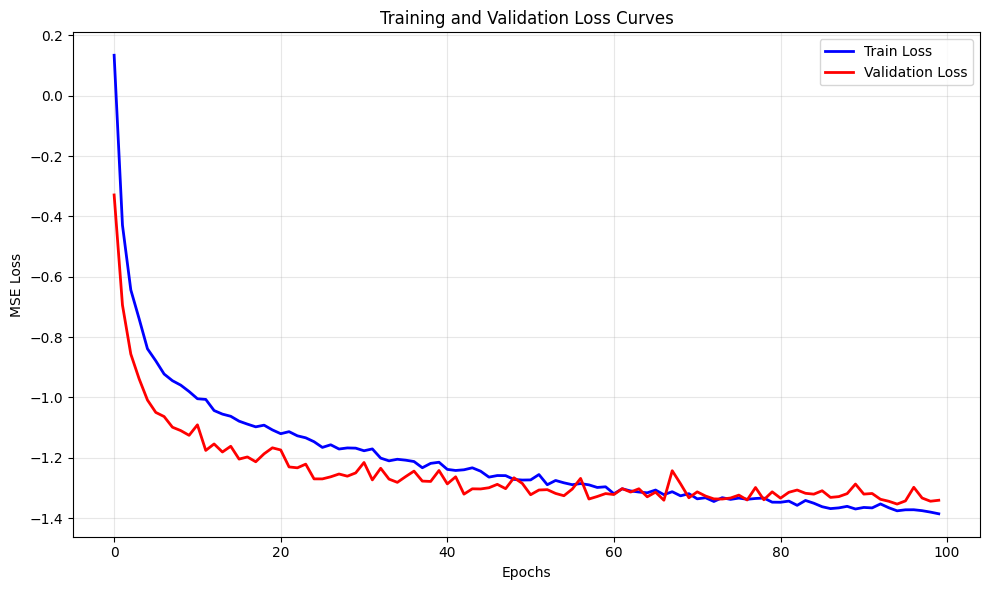

In [27]:
# Plot training/validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss", color="blue", linewidth=2)
plt.plot(val_losses, label="Validation Loss", color="red", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

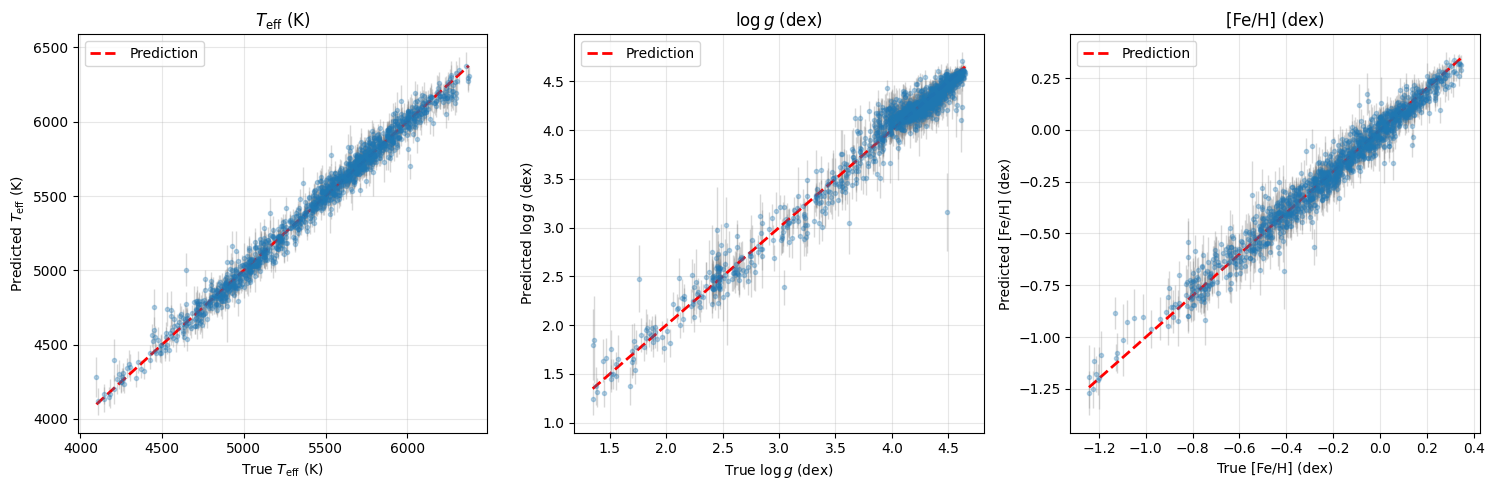

t_eff correlation: 0.9919
log_g correlation: 0.9848
fe_h correlation: 0.9813


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


pred_denorm = physical_means.numpy()
true_denorm = physical_targets.numpy()
stds_denorm = physical_stds.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


label_names = [r"$T_{\mathrm{eff}}$ (K)", r"$\log g$ (dex)", r"[Fe/H] (dex)"]

for i, (name, ax) in enumerate(zip(label_names, axes)):
    
    ax.errorbar(true_denorm[:, i], pred_denorm[:, i], yerr=stds_denorm[:, i], 
                fmt='o', alpha=0.3, markersize=3, ecolor='gray', elinewidth=1, capsize=0)
    
    
    min_val = true_denorm[:, i].min()
    max_val = true_denorm[:, i].max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prediction')
    
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot1.jpg", format='jpg', dpi=450)
plt.show()


for i, name in enumerate(["t_eff", "log_g", "fe_h"]):
    corr = np.corrcoef(true_denorm[:, i], pred_denorm[:, i])[0, 1]
    print(f"{name} correlation: {corr:.4f}")

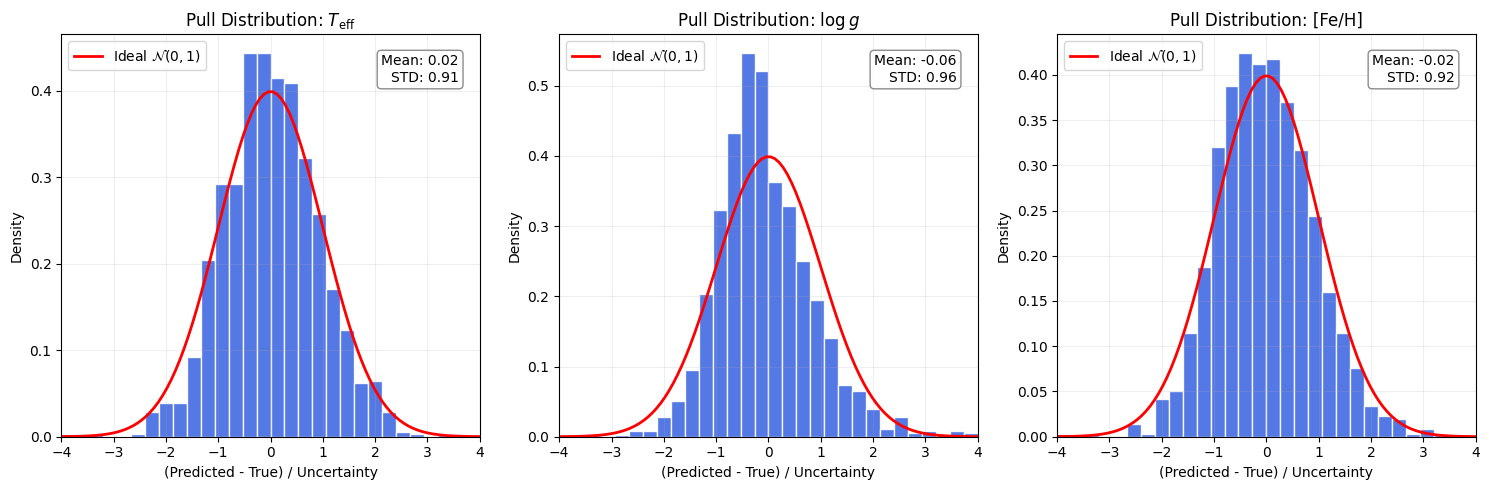

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


label_names = [r"$T_{\mathrm{eff}}$", r"$\log g$", r"[Fe/H]"]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (name, ax) in enumerate(zip(label_names, axes)):
    
    pull = (pred_denorm[:, i] - true_denorm[:, i]) / stds_denorm[:, i]
    
    mu_pull = np.mean(pull)
    std_pull = np.std(pull)
    
    ax.hist(pull, bins=30, range=(-4, 4), density=True, 
            color='royalblue', edgecolor='white', alpha=0.9)
    
    x_axis = np.linspace(-4, 4, 100)
    ideal_pdf = norm.pdf(x_axis, loc=0, scale=1)
    ax.plot(x_axis, ideal_pdf, 'r-', linewidth=2, label=r'Ideal $\mathcal{N}(0,1)$')
    
    textstr = f'Mean: {mu_pull:.2f}\nSTD: {std_pull:.2f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    ax.set_xlabel('(Predicted - True) / Uncertainty')
    ax.set_ylabel('Density')
    ax.set_title(f'Pull Distribution: {name}')
    ax.set_xlim(-4, 4)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("plot2.jpg", format='jpg', dpi=450)
plt.show()